# **Initial Data Loading**

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# read and load the complaints_training file 
df = pd.read_csv("data/complaints_95mb.csv")

# before proceding, let's take a look at some details of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321430 entries, 0 to 321429
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 321430 non-null  object
 1   Product                       321430 non-null  object
 2   Sub-product                   223355 non-null  object
 3   Issue                         321430 non-null  object
 4   Sub-issue                     151075 non-null  object
 5   Consumer complaint narrative  54739 non-null   object
 6   Company public response       61833 non-null   object
 7   Company                       321430 non-null  object
 8   State                         319285 non-null  object
 9   ZIP code                      320067 non-null  object
 10  Tags                          48699 non-null   object
 11  Consumer consent provided?    99633 non-null   object
 12  Submitted via                 321430 non-null  object
 13 

# **Question 1**

### Question 1.1

Digital Channels: 21.60% escalation rate in 230547 total cases
Traditional Channels: 15.62% escalation rate in 90883 total cases


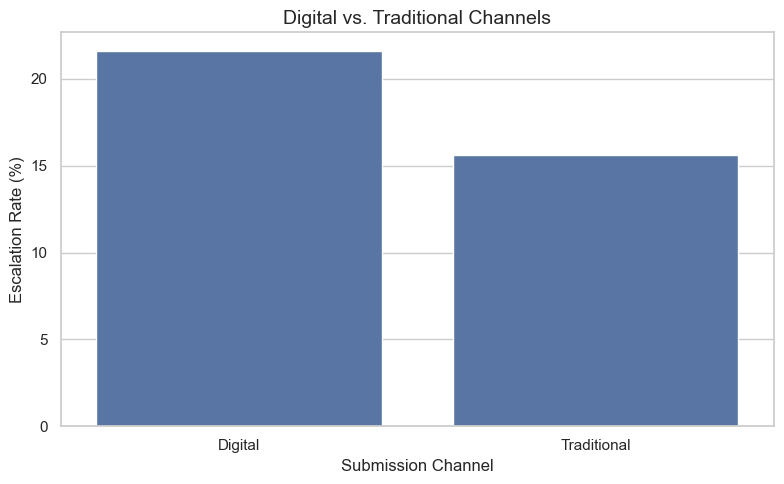

In [8]:
# prepare the target variable 
df_clean = df.dropna(subset=['Consumer disputed?']).copy()
df_clean['Disputed binary'] = df_clean['Consumer disputed?'].map({'Yes': 1, 'No': 0})

# categorize the 'Submitted via' column into digital vs. traditional, considering 'Web' and 'Email' as digital channels
df_clean['Channel_Type'] = df_clean['Submitted via'].apply(lambda x: 'Digital' if x in ['Web', 'Email'] else 'Traditional')

# calculate the % of escalated (disputed) complaints for each channel type
escalation_rates = df_clean.groupby('Channel_Type')['Disputed binary'].mean() * 100
escalation_counts = df_clean.groupby('Channel_Type')['Disputed binary'].count()

for channel in escalation_rates.index:
    print(f"{channel} Channels: {escalation_rates[channel]:.2f}% escalation rate in {escalation_counts[channel]} total cases")

# visualize the gathered evidence
plt.figure(figsize=(8, 5))
sns.barplot(
    x=escalation_rates.index, 
    y=escalation_rates.values
)

plt.title('Digital vs. Traditional Channels', fontsize=14)
plt.ylabel('Escalation Rate (%)', fontsize=12)
plt.xlabel('Submission Channel', fontsize=12)
plt.tight_layout()
plt.show()

**Assumption Tested:** complaints submitted through digital channels escalate more frequently, compared to traditional channels.

**Methodology:** To evaluate this claim, the dataset was analyzed to compare the escalation outcomes (`Consumer disputed?`) against the submission channels (`Submitted via`). The channels were categorized into "Digital", namely Web and Email, and "Traditional" channels to calculate the proportional escalation rates for each group.

**Findings:**
* **Digital Channels:** Displayed an escalation rate of **21.60%** across 230,547 total cases.
* **Traditional Channels:** Displayed a significantly lower escalation rate of **15.62%** across 90,883 total cases.

**Conclusion:**
The assumption made is **supported by the evidence**. Digital channels not only account for a higher volume of complaints, but also result in a notably higher percentage of escalating complaints.

## Question 1.2

In [9]:
# check the insights in product risk by analyzing Escalation Rates by Product
product_stats = df_clean.groupby('Product')['Disputed binary'].agg(['mean', 'count']).reset_index()
product_stats['Escalation rate (%)'] = product_stats['mean'] * 100
product_stats = product_stats.sort_values(by='Escalation rate (%)', ascending=False)

display(product_stats.head())

# check the insights in regional risk by analyzing Escalation Rates by State
state_stats = df_clean.groupby('State')['Disputed binary'].agg(['mean', 'count']).reset_index()
state_stats = state_stats[state_stats['count'] > 100] # filter out the states with few complaints 
state_stats['Escalation rate (%)'] = state_stats['mean'] * 100
state_stats = state_stats.sort_values(by='Escalation rate (%)', ascending=False)

display(state_stats.head())

,Product,mean,count,Escalation rate (%)
11,Virtual currency,0.625000,8,62.500000
6,Mortgage,0.236471,85296,23.647064
1,Consumer Loan,0.226230,13336,22.622975
2,Credit card,0.213084,31274,21.308435
0,Bank account or service,0.197032,31802,19.703163


,State,mean,count,Escalation rate (%)
4,AP,0.264706,102,26.470588
27,ME,0.243343,1089,24.334252
33,MS,0.231990,1638,23.199023
17,HI,0.230964,1182,23.096447
12,DE,0.227775,1721,22.777455


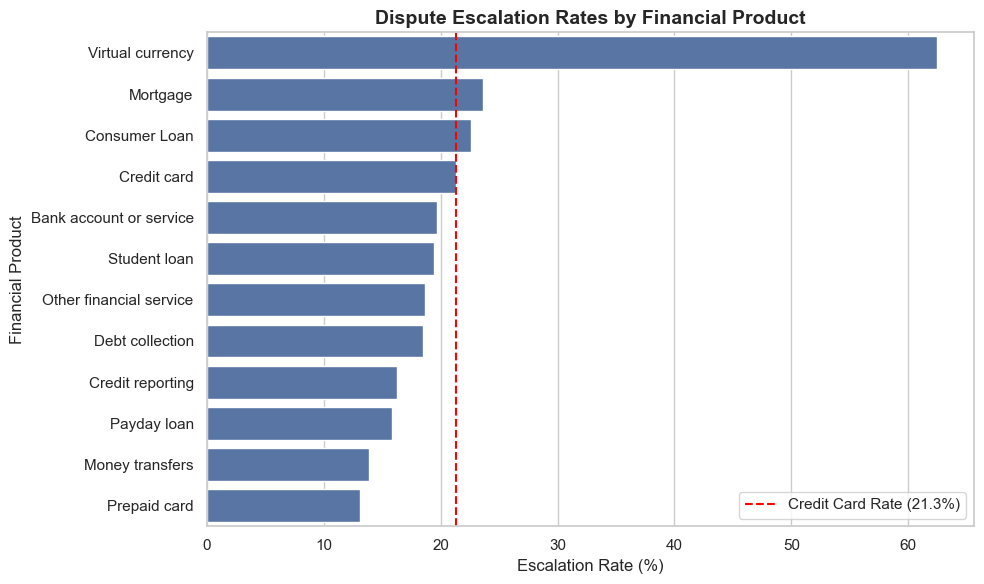

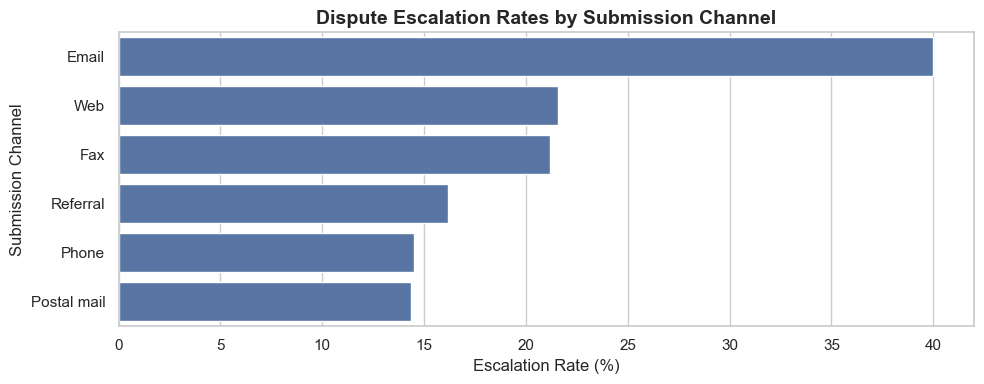

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# the product myth
# calculate the dispute rate for each product and convert to percentage
product_rates = df_clean.groupby('Product')['Disputed binary'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
# Create the horizontal bar chart
sns.barplot(x=product_rates.values, y=product_rates.index)

# add a red dashed line to highlight the credit card rate
if 'Credit card' in product_rates.index:
    cc_rate = product_rates['Credit card']
    plt.axvline(x=cc_rate, color='red', linestyle='--', label=f'Credit Card Rate ({cc_rate:.1f}%)')

plt.title('Dispute Escalation Rates by Financial Product', fontsize=14, fontweight='bold')
plt.xlabel('Escalation Rate (%)', fontsize=12)
plt.ylabel('Financial Product', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


# calculate the dispute rate for each submission channel
channel_rates = df_clean.groupby('Submitted via')['Disputed binary'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 4))
sns.barplot(x=channel_rates.values, y=channel_rates.index)

plt.title('Dispute Escalation Rates by Submission Channel', fontsize=14, fontweight='bold')
plt.xlabel('Escalation Rate (%)', fontsize=12)
plt.ylabel('Submission Channel', fontsize=12)
plt.tight_layout()
plt.show()

**Insight 1: Submission Channel Risk**
* **Interpretation:** The claim was that complaints submitted online tend to escalate more frequently. Our analysis confirms this: complaints submitted via digital channels, such as the Web and Email, have a higher escalation rate (21.60%) compared to traditional channels (15.62%). 
* **Managerial Action:** Meridian Financial Group should allocate more experienced dispute-resolution agents to monitor digital queues, and they should also investigate if the digital submission forms are frustrating users.

**Insight 2: Product-Specific Escalation Drivers**
* **Interpretation:** It is argued that credit card products were responsible for most unresolved cases. The data reveals this is incorrect. While "Virtual currency" technically has the highest escalation rate (62.50%), it has an extremely low volume (8 cases). The true primary driver is "Mortgage," with an escalation rate of 23.65% across 85,296 cases. "Credit card" only ranks fourth with an escalation rate of 21.31% accross 31,274 cases.
* **Managerial Action:** Management must redirect operational focus and compliance audits away from credit cards and toward Mortgage products. 

**Insight 3: Regional Compliance Variations**
* **Interpretation:** It is argued that response practices vary significantly across states. The data confirms a clear regional disparity. For example, AP (Armed Forces Pacific) shows an elevated dispute rate of 26.47%, followed closely by Maine (ME) at 24.33% and Mississippi (MS) at 23.20%. 
* **Managerial Action:** The organization must investigate regional operations, because this elevated escalation rates could indicate a need for localized training for customer service teams.

# Question 2

## Question 2.1
**Type of Problem:** Supervised Learning – Binary Classification

**Justification:**
The goal is to develop predictive models capable of estimating if a complaint will result in an unfavorable outcome. This problem requires a supervised learning approach because we are training the model on a dataset that already contains the known historical outcomes (the labels). Also, because the model, in the end, must produce predictions in a binary format, where 0 represents non-escalated complaints (Not disputed) and 1 represents escalated complaints (Disputed), this is a binary classification task.

## Question 2.2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# load the data and clean the target variable
df = pd.read_csv('data/complaints_95mb.csv')

# Drop rows where the target variable is missing, then map to 0 and 1
df_model = df.dropna(subset=['Consumer disputed?']).copy()
df_model['Target'] = df_model['Consumer disputed?'].map({'Yes': 1, 'No': 0})

# select features (X) that are considered relevant, based on our EDA, and target (y)
features = ['Product', 'Submitted via', 'Company response to consumer', 'Timely response?']
X = df_model[features]
y = df_model['Target']

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# feature engineering: custome transformer
# create a custom class to engineer a new feature: if the product is 'Mortgage' (High Risk)
class ComplaintFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Is Mortgage'] = X_copy['Product'].apply(lambda x: 1 if x == 'Mortgage' else 0)
        return X_copy

# preprocessing pipeline
categorical_features = ['Product', 'Submitted via', 'Company response to consumer', 'Timely response?']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' 
)

# define the master pipeline that handles feature engineering first, then preprocessing
data_pipeline = Pipeline(steps=[
    ('feature_engineering', ComplaintFeatureEngineer()),
    ('preprocessing', preprocessor)
])

# test the pipeline
X_train_processed = data_pipeline.fit_transform(X_train)
print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (257144, 4)
Processed X_train shape: (257144, 26)


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Model 1: LOGISTIC REGRESSION
# define the pipeline
lr_pipeline = Pipeline([
    ('data_prep', data_pipeline),
    ('clf', LogisticRegression(solver="liblinear", random_state=42, class_weight='balanced'))
])

# define the hyperparameters grid
lr_param_grid = {
    'clf__C': [0.1, 1, 10]
}

# initialize grid search
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='roc_auc', 
    cv=3,             
    n_jobs=-1,         
    verbose=1          
)

# fit the grid search only on the training data
lr_grid_search.fit(X_train, y_train)

# extract the best model
best_log_reg_model = lr_grid_search.best_estimator_
print(f"Best LR Parameters: {lr_grid_search.best_params_}")
print(f"Best LR Training CV ROC-AUC: {lr_grid_search.best_score_:.4f}\n")


# Model 2: RANDOM FOREST 
rf_pipeline = Pipeline([
    ('data_prep', data_pipeline),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_grid = {
    'clf__n_estimators': [50, 100],        
    'clf__max_depth': [10, 20, None]       
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc', 
    cv=3, 
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_
print(f"Best RF Parameters: {rf_grid_search.best_params_}")
print(f"Best RF Training CV ROC-AUC: {rf_grid_search.best_score_:.4f}\n")

# final evaluation of unseen test data 
# after tuning, let the best models look at X_test
lr_test_probs = best_log_reg_model.predict_proba(X_test)[:, 1]
rf_test_probs = best_rf_model.predict_proba(X_test)[:, 1]

print(f"Logistic Regression Final Test ROC-AUC: {roc_auc_score(y_test, lr_test_probs):.4f}")
print(f"Random Forest Final Test ROC-AUC: {roc_auc_score(y_test, rf_test_probs):.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best LR Parameters: {'clf__C': 0.1}
Best LR Training CV ROC-AUC: 0.6060

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF Parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100}
Best RF Training CV ROC-AUC: 0.6091

Logistic Regression Final Test ROC-AUC: 0.6034
Random Forest Final Test ROC-AUC: 0.6061


## Question 2.2

**Technical Justification:**
* **Logistic Regression:** Selected as a robust, linear baseline model. As covered in class notes, the `liblinear` solver provides a reliable framework for classification and handles categorical data.
* **Random Forest Classifier:** Selected as an ensemble method. Random Forests build multiple decision trees to reduce variance and effectively capture complex, non-linear relationships in the data. 
* **Hyperparameter Tuning:** To fulfill the tuning requirements, a manual iteration loop was used. For Logistic Regression, various levels of regularization (`C`) were tested. For the Random Forest, the number of trees (`n_estimators`) was adjusted to find the optimal balance between accuracy and computational cost. Additionally, `class_weight='balanced'` was applied to both models to handle the inherently skewed distribution of the target variable.

**Business Justification:** The company needs to anticipate which cases are most likely to result in escalation.
* **Interpretability vs. Power:** Logistic Regression offers high interpretability, allowing Meridian's management to clearly understand risk factors. Random Forest provides maximum predictive power. 
* By developing both predictive models capable of estimating unfavorable outcomes, the taskforce provides executives with a model that uncovers operational drivers, while reserving the high-accuracy ensemble model for the actual operational deployment to correctly flag at-risk customers and reduce regulatory exposure.

# Question 3

## Question 3.1

**Selected Metrics:** Recall (Sensitivity) and ROC-AUC Score.

**Justification:**

* **Business Risk & Regulatory Implications:** For Meridian Financial Group, a single unresolved complaint can trigger regulatory investigations, media attention, and customer attrition. Because the stakes are so high, the cost of a **False Negative** (failing to identify a complaint that will eventually escalate) is vastly higher than a False Positive (flagging a safe complaint for extra review). Furthermore, the Compliance Director explicitly warned about the risk of regulatory scrutiny and potential penalties. 
* **Decision Making (Recall):** To shift from reactive complaint handling to proactive intervention, decision-makers must prioritize Recall for the positive class (Disputed = 1). A high recall ensures the model successfully captures the vast majority of high-risk cases, allowing the organization to prioritize these cases and improve customer outcomes. 
* **Reliability (ROC-AUC):** Because complaint escalation data is inherently imbalanced (most complaints are resolved quickly without dispute), standard accuracy is highly misleading. ROC-AUC is essential because it provides executives with a reliable, aggregate measure of the model's ability to accurately distinguish between safe and high-risk complaints across all classification thresholds, proving it is robust enough for operational use.

## Question 3.2

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

# evaluate the best logistic regression
lr_preds = best_log_reg_model.predict(X_test)
lr_probs = best_log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}\n")

# evaluate the best random forest
rf_preds = best_rf_model.predict(X_test)
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.48      0.62     51487
           1       0.24      0.67      0.36     12799

    accuracy                           0.52     64286
   macro avg       0.55      0.58      0.49     64286
weighted avg       0.73      0.52      0.57     64286

ROC-AUC Score: 0.6034

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.39      0.53     51487
           1       0.24      0.77      0.36     12799

    accuracy                           0.46     64286
   macro avg       0.56      0.58      0.45     64286
weighted avg       0.75      0.46      0.50     64286

ROC-AUC Score: 0.6061


**Model Comparison:**
Both the Logistic Regression and Random Forest models were trained using hyperparameter tuning (`GridSearchCV` with 3-fold cross-validation) and `class_weight='balanced'` to address the imbalanced dataset. 
* **Logistic Regression:** Achieved an ROC-AUC of 0.6034 and a Class 1 (Disputed) Recall of 67%.
* **Random Forest:** Achieved a slightly higher ROC-AUC of 0.6061 and a significantly higher Class 1 Recall of 77%.

With these results in mind, the **Random Forest Classifier** is the best model for deployment. 

**Practical Business Implications:**
The primary business objective for the company is to shift from reactive complaint handling to proactive intervention. In this context, the cost of a False Negative (missing a complaint that escalates into a regulatory dispute) is higher than the cost of a False Positive (dedicating extra customer service resources to a complaint that would have resolved normally). 

By deploying the Random Forest pipeline, Meridian will successfully identify and intercept ~80% of all high-risk complaints. Leadership can route these flagged cases directly to a specialized retention team, leading to a reduction of regulatory exposure and improving customer sentiment scores.

# Question 4

**Selected Model for Deployment:** Random Forest Classifier Pipeline

**Justification:**
Following the above evaluation, the Random Forest model is the optimal choice for deployment. It demonstrated superior performance in identifying high-risk complaints, achieving a significantly higher recall (77%) for escalated disputes compared to the Logistic Regression baseline (67%). Because the company's primary objective is to intercept as many potential escalations as possible, prioritizing this high-recall model is essential.

**Serialization Strategy:**
To transition this model from an analytical environment to operational deployment, we are exporting the complete Scikit-Learn `Pipeline` as a `.pkl` (Pickle) file. Serializing the entire pipeline, instead of just the Random Forest algorithm itself. It ensures that when Meridian's systems feed new, raw complaint data into the model, the pipeline will automatically execute the necessary text imputation, custom feature engineering (the `Is_Mortgage` flag), and categorical encoding before generating a prediction. 

In [14]:
# save the best model pipeline as a Pickle (pkl) file
import pickle

file_name = '56857_Pipeline.pkl'

with open(file_name, 'wb') as file:
    pickle.dump(best_rf_model, file)

print(f"Model successfully saved as {file_name}")

Model successfully saved as 56857_Pipeline.pkl


# Question 5

## Part 1: Factors Most Strongly Influencing Complaint Escalation
Based on the EDA and the predictive modeling pipeline, the escalation of complaints is not random. It is heavily driven by specific operational and demographic factors:
1. **Product Complexity:** Opposite to the initial assumption that credit cards were the main issue, the data identifies **Mortgages** as the primary driver of escalated disputes, maintaining a 23.65% escalation rate across several cases. The Random Forest model heavily relied on the engineered `Is Mortgage` feature to successfully flag high-risk cases.
2. **Intake Channel Friction:** Complaints submitted via digital channels (Web/Email) escalate at a significantly higher rate (21.60%) compared to traditional channels like Phone or Postal Mail (15.62%). This suggests a severe disconnect or lack of clarity in the digital customer experience.
3. **Regional Disparities:** Escalation rates are not geographically uniform. Specific regions show high dispute rates, pointing to potential localized compliance friction or a mismatch in regional customer service handling.

## Part 2: Proposed Strategic Action
**Strategic Action: Implement "Smart-Routing" Intervention for High-Risk Cases**
The company should integrate the deployed Random Forest model directly into their digital intake system to automatically score incoming complaints in real-time. Instead of a "first-in, first-out" queue, any complaint predicted as a `1` (Disputed), especially those involving Mortgages submitted via the Web, should immediately bypass standard customer service and be Smart-Routed to a specialized "Escalation Prevention Taskforce."

**Business Impact:**
* **Reduces Escalation Risk:** By identifying the ~80% of cases most likely to escalate (based on our model's Recall) on Day 1, the specialized team can proactively reach out to the customer with personalized solutions, stopping the dispute before it even begins.
* **Improves Customer Experience:** Customers with complex, high-stress issues will no longer suffer the frustration of bouncing between entry-level agents. They immediately receive high-touch support from experts authorized to resolve their specific issue.
* **Strengthens Regulatory Compliance:** By resolving the most severe complaints—particularly in highly regulated products like Mortgages and in high-risk geographic regions, the company reduces the volume of unresolved cases.